Preuzimam mapu za: Novi Sad, Serbia. Ovo može potrajati minut-dva...
Mapa uspešno preuzeta!
Broj čvorova (raskrsnica): 2786
Broj grana (ulica): 6644


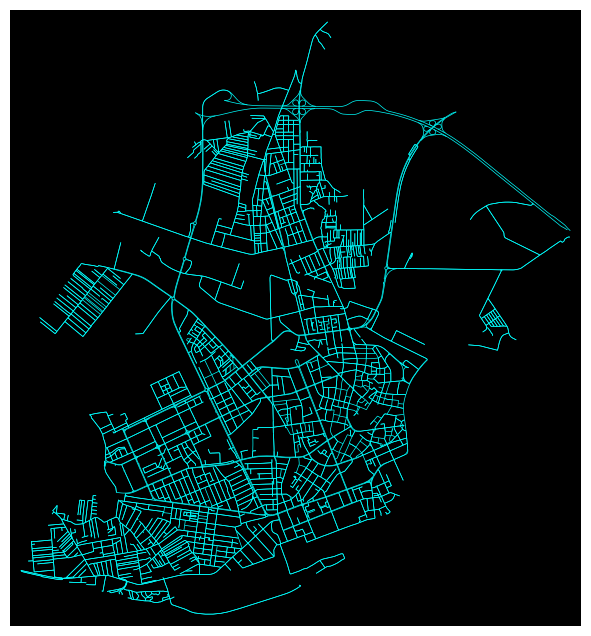

In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Definišemo mesto koje preuzimamo
place_name = "Novi Sad, Serbia"

print(f"Preuzimam mapu za: {place_name}. Ovo može potrajati minut-dva...")

# Preuzimamo usmereni graf putne mreže (samo putevi za automobile)
G = ox.graph_from_place(place_name, network_type='drive')

# Ispisujemo osnovne informacije o grafu
num_nodes = len(G.nodes)
num_edges = len(G.edges)
print("Mapa uspešno preuzeta!")
print(f"Broj čvorova (raskrsnica): {num_nodes}")
print(f"Broj grana (ulica): {num_edges}")

# Iscrtavamo preuzeti graf
fig, ax = ox.plot_graph(G, node_size=0, edge_color="cyan", edge_linewidth=0.5, bgcolor="black")

ID pocetnog cvora (Hitna pomoc): 551962685
ID ciljnog cvora (Mesto nesrece): 1533391269
Iscrtavam korigovane lokacije na mapi...


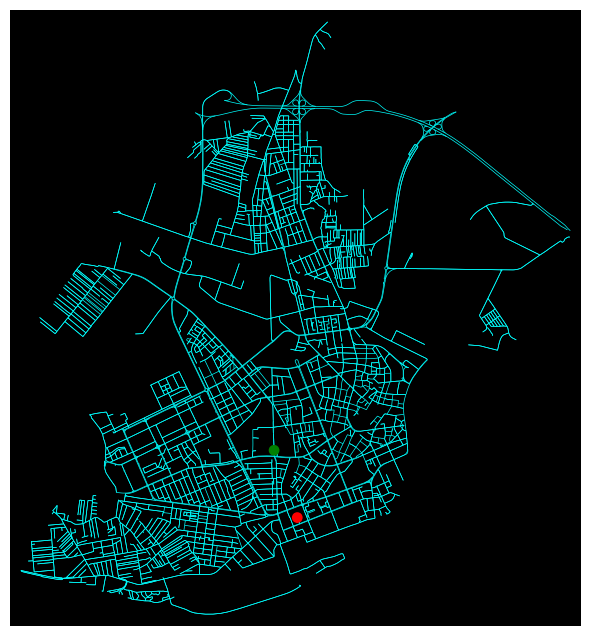

In [4]:
# Tacne koordinate Klinickog centra Vojvodine (Pocetak - Hitna pomoc)
start_lat, start_lon = 45.2508, 19.8236

# Koordinate mesta nesrece (Npr. lokacija negde na Limanu/Grbavici)
goal_lat, goal_lon = 45.2400, 19.8300

# TRAZENJE NAJBLIZIH CVOROVA U GRAFU
# Napomene: osmnx funkcija prvo trazi X (longitude), pa onda Y (latitude)
start_node = ox.nearest_nodes(G, start_lon, start_lat)
goal_node = ox.nearest_nodes(G, goal_lon, goal_lat)

print(f"ID pocetnog cvora (Hitna pomoc): {start_node}")
print(f"ID ciljnog cvora (Mesto nesrece): {goal_node}")

# VIZUELIZACIJA TACAKA NA MAPI
# Bojimo startni cvor u zeleno, ciljni u crveno, ostale ostavljamo nevidljive
node_colors = ['green' if node == start_node else 'red' if node == goal_node else 'none' for node in G.nodes()]
node_sizes = [60 if node in [start_node, goal_node] else 0 for node in G.nodes()]

print("Iscrtavam korigovane lokacije na mapi...")
fig, ax = ox.plot_graph(
    G, 
    node_color=node_colors, 
    node_size=node_sizes, 
    edge_color="cyan", 
    edge_linewidth=0.5, 
    bgcolor="black"
)

In [ ]:
import time
from src.state import MapNodeState
from src.search import BreadthFirstSearch, DepthFirstSearch, UniformCostSearch, AStarSearch
import osmnx as ox

# 1. INICIJALIZACIJA POČETNOG STANJA
# start_node i goal_node su ostali sačuvani u memoriji iz prethodne ćelije
initial_state = MapNodeState(graph=G, parent=None, current_node=start_node, goal_node=goal_node, edge_cost=0)

# 2. ODABIR ALGORITMA
# Za prvi test pokrećemo A* (A-Star) jer je najinteligentniji i najbrži
algorithm = AStarSearch()
print("Pokrećem A* algoritam. Molim sačekajte...")

# 3. POKRETANJE PRETRAGE I MERENJE VREMENA
start_time = time.time()
path, processed_list, states_list = algorithm.search(initial_state)
end_time = time.time()

# 4. PRIKAZ METRIKA (Kao što je traženo u specifikaciji projekta)
if path is not None:
    execution_time = (end_time - start_time) * 1000 # Konverzija u milisekunde
    
    # Da bismo dobili pravu cenu puta (u metrima), moramo naći stanje ciljnog čvora
    # Znamo da je to poslednje stanje u processed_list koje je finalno
    final_state_obj = next((state for state in processed_list if state.is_final_state()), None)
    total_distance = final_state_obj.get_current_cost() if final_state_obj else 0
    
    print(f"\n--- REZULTATI PRETRAGE (A* Algoritam) ---")
    print(f"Putanja uspešno pronađena!")
    print(f"Vreme izvršavanja: {execution_time:.2f} ms")
    print(f"Broj ekspandiranih (posećenih) čvorova: {len(processed_list)}")
    print(f"Ukupna dužina pronađene rute: {total_distance:.2f} metara")
    
    # 5. VIZUELIZACIJA RUTE NA MAPI
    print("\nIscrtavam pronađenu rutu na mapi...")
    fig, ax = ox.plot_graph_route(
        G, 
        path, 
        route_color="red", 
        route_linewidth=4, 
        node_size=0, 
        bgcolor="black"
    )
else:
    print("Greška: Putanja nije pronađena!")